In [1]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print
from utils.pd_utils import sort_cycle

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

from vis_utils.rnaseqTools import geneSelection, sparseload
import pickle
import torch
import urllib.request
import requests
 

env: CUDA_VISIBLE_DEVICES=1
[KeOps] Warning : cuda was detected, but driver API could not be initialized. Switching to cpu only.


# path

In [2]:
root_path = get_path("data")
fig_path = os.path.join(root_path, "figures")
seeds = [0]
k = 15

In [3]:
style_file = "utils.style"
plt.style.use(style_file)

In [18]:
distances = {
    "euclidean": [{}],
    # "diffusion": [
    #     {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
    #     {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
    #     {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
    #     {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    #     # {"k": 100, "t": 128, "kernel": "sknn", "include_self": False},
    #     # {"k": 200, "t": 64, "kernel": "sknn", "include_self": False},
    #     # {"k": 200, "t": 128, "kernel": "sknn", "include_self": False},
    # ],
    # "eff_res": [
    #     {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
    #     {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    #     # {"corrected": True, "weighted": False, "k": 200, "disconnect": True},
    #     # {"corrected": True, "weighted": False, "k": 300, "disconnect": True},
    # ],
}

In [5]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
# seed = 0
file_name = os.path.join(root_path,
                         "yao_10x_male",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_0_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [6]:
def reorder_yaxis(item):
    number, letter = item.split('_')
    return (letter, 300-int(number))

In [7]:
def smooth_curve(nums): # only if isolated...
    if len(nums) < 3:
        return nums
    
    result = [nums[0]]  

    for i in range(1, len(nums) - 1):
        if nums[i] == nums[i - 1] or nums[i] == nums[i + 1]:
            result.append(nums[i])

    result.append(nums[-1])
    
    lens = len(result)

    return result, lens

In [8]:
def compute_density(cell_list, cluster_template):
    lens = len(cell_list)
    density = []
    for cluster in cluster_template:
        count = cell_list.count(cluster)
        density.append(count)
    # print(density)
    density = np.array(density)/lens
    return density

# mask making

In [9]:
_, _, _, _, full_d = load_dataset(root_path, "yao_10x_male", k=k)

In [10]:
#cannot really find "Serpinf1", but on the paper according to fig 2D, it should be 21_ to 24_, and 41_ and 40_, so its already included in vip and Sncg
#but should i also included _Ntng1, according to fig 2D..... and lamp5_pax6 is labeled as "_Pax6, so i also added it in.... 
idx_purple = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
cluster_purple = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
idx_orange = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
cluster_orange = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]

In [11]:
mask_purple = [idx in idx_purple for idx in full_d['clusters']]
idx_mask_purple = [i for i, idx in enumerate(full_d['clusters']) if idx in idx_purple ]
mask_orange = [idx in idx_orange for idx in full_d['clusters']]
idx_mask_orange = [i for i, idx in enumerate(full_d['clusters']) if idx in idx_orange]


In [69]:

folders  = [os.path.join(root_path, f) for f in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, f)) and f.startswith("yao_10x_male_purple_sample_")]

In [74]:
submask_purple = [np.load(os.path.join(f, "mask.npy")) for f in folders]

In [81]:
embd[mask_purple][submask_purple[0].tolist()]

array([[-62.54539191, -19.97645486],
       [-65.72485451,  19.04778891],
       [-58.25068008, -12.09319026],
       ...,
       [-61.14232896, -21.58765622],
       [-63.17817703, -19.61601022],
       [-52.11729425,  -0.43974651]])

In [ ]:
embd_purple_10x = embd[mask_purple][mm_p_1]

In [ ]:
np.save(os.path.join(root_path, "embd_x_mask_purple_sample.npy"), embd_purple_10x)

In [ ]:
embd_orange_10x = embd[mask_orange][mm_o_0]

In [ ]:
np.save(os.path.join(root_path, "embd_x_mask_orange_sample.npy"), embd_orange_10x)

# purple parameters

In [12]:
x, y, sknn, pca2, d = load_dataset(root_path, "yao_10x_male_purple", k=15, seed=0)

In [15]:
all_res = load_multiple_res(datasets="yao_10x_male_purple_0_10k", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with yao_10x_male_purple_0_10k None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_100_t_128_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_200_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None diffusion_k_200_t_128_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_0_10k None eff

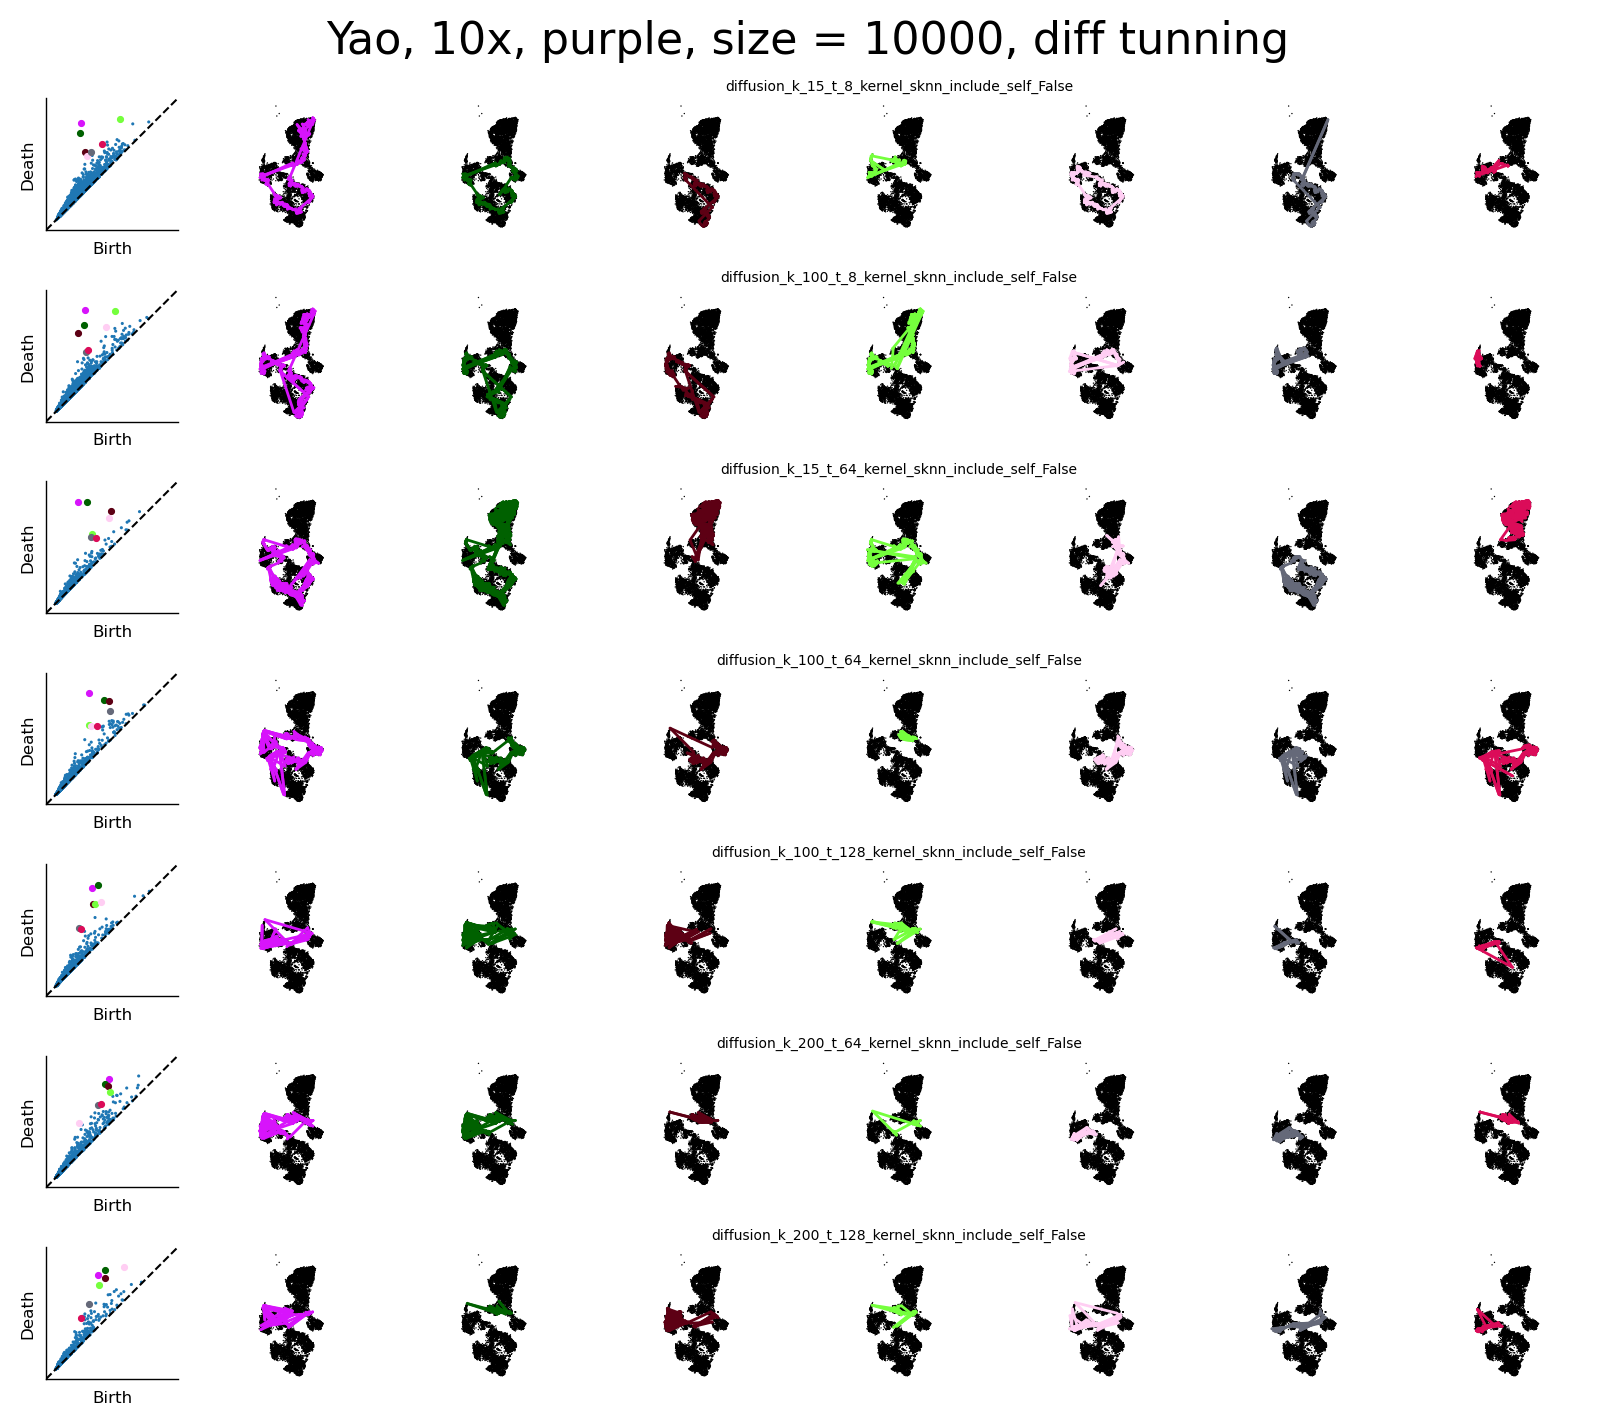

In [16]:
n_exp = len(all_res['diffusion'])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, n_exp), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0

for j, full_dist in enumerate(all_res['diffusion']):
    res = all_res['diffusion'][full_dist]    #[seed]        
    if len(res["dgms"][1]) != 0:
        np.random.seed(0)
        mm_p = np.random.choice(len(idx_mask_purple), 10000, replace=False)
        ax[row][int(mid_col)].set_title(full_dist, fontsize=5) 
        plot_dgm_loops(res, embd[mask_purple][mm_p], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops) #mask_orange
    else:
        ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
        revised = res["dgms"]
        # revised[1] = np.array([[0,0],[1,1]])
        revised[1] = np.zeros((1,2))
        ax0 = ax[row][0]
        ax0.legend().set_visible(False)
        ax0.set_xticks([])
        ax0.set_yticks([])
        ax0.set_ylabel("Death")
        ax0.set_xlabel("Birth")
        plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
        # ax0.plot([-1, 1], [-1, 1], "--", c = 'k', markersize=0.1)
        for i in range(n_cols-1):
            plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
    for s in range(n_cols-1):
        ax[row][s+1].set_ylim(-30, 40)
    
    ax[row][0].legend().set_visible(False)
    ax[row][0].set_xticks([])
    ax[row][0].set_yticks([])
    ax[row][0].set_ylabel("Death")
    # ax[row][int(mid_col)].set_title(full_dist)
    row+=1
fig.suptitle("Yao, 10x, purple, size = 10000, diff tunning", fontsize = 16)       
plt.show()

fig.savefig(os.path.join(get_path("figures"), "purple_10x_10k_diff.png"), dpi=300)


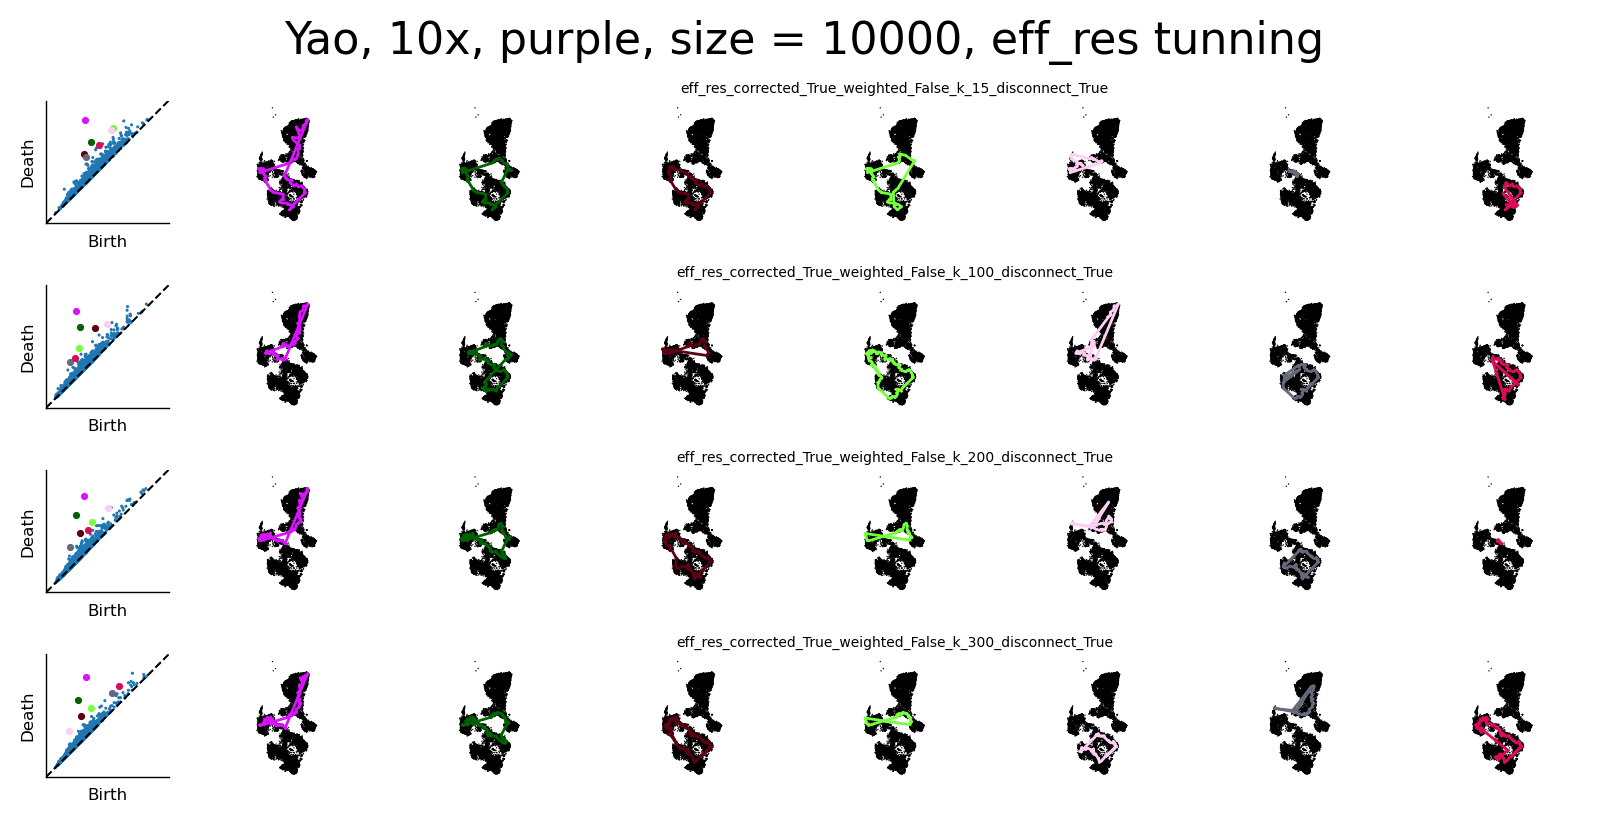

In [17]:
n_exp = len(all_res['eff_res'])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, n_exp), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0

for j, full_dist in enumerate(all_res['eff_res']):
    res = all_res['eff_res'][full_dist]    #[seed]        
    if len(res["dgms"][1]) != 0:
        np.random.seed(0)
        mm_p = np.random.choice(len(idx_mask_purple), 10000, replace=False)
        ax[row][int(mid_col)].set_title(full_dist, fontsize=5) 
        plot_dgm_loops(res, embd[mask_purple][mm_p], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops) #mask_orange
    else:
        ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
        revised = res["dgms"]
        # revised[1] = np.array([[0,0],[1,1]])
        revised[1] = np.zeros((1,2))
        ax0 = ax[row][0]
        ax0.legend().set_visible(False)
        ax0.set_xticks([])
        ax0.set_yticks([])
        ax0.set_ylabel("Death")
        ax0.set_xlabel("Birth")
        plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
        # ax0.plot([-1, 1], [-1, 1], "--", c = 'k', markersize=0.1)
        for i in range(n_cols-1):
            plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
    for s in range(n_cols-1):
        ax[row][s+1].set_ylim(-30, 40)
    
    ax[row][0].legend().set_visible(False)
    ax[row][0].set_xticks([])
    ax[row][0].set_yticks([])
    ax[row][0].set_ylabel("Death")
    # ax[row][int(mid_col)].set_title(full_dist)
    row+=1
fig.suptitle("Yao, 10x, purple, size = 10000, eff_res tunning", fontsize = 16)       
plt.show()

fig.savefig(os.path.join(get_path("figures"), "purple_10x_10k_eff.png"), dpi=300)


# Purple

## load data

In [83]:
x, y, sknn, pca2, d = load_dataset(root_path, "yao_10x_male_purple", k=15, seed=0)
all_res = load_multiple_res(datasets="yao_10x_male_purple_sample", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with yao_10x_male_purple_sample None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


## color demo

[]

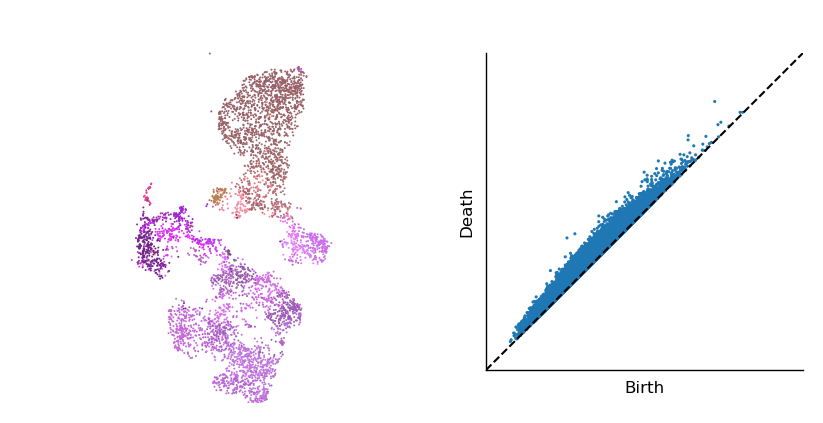

In [84]:
n_cols = 2
plot_loops = False

width_ratios = [0.75] + [1] * (n_cols - 1)

seed = 0
size = 1

distance = "euclidean"
full_dist = "euclidean"

res = all_res[distance][full_dist]
fig, ax = plt.subplots(nrows=1, ncols=n_cols, figsize=(4, 2), constrained_layout=True, width_ratios=width_ratios[::-1])

# plot_dgm_loops(res, embd=embd[mask_purple][mm_p], y=d['clusterColors'][d['clusters']][mm_p], n_loops=0, ax=ax[::-1], plot_only=[1],
            #    style=style_file, linewidth=1, plot_loops=plot_loops, s=2)
plot_dgm_loops(res, embd=embd[mask_purple][submask_purple[0].tolist()], y=d['clusterColors'][d['clusters']][submask_purple[0].tolist()], n_loops=0, ax=ax[::-1], plot_only=[1],
               style=style_file, linewidth=1, plot_loops=plot_loops, s=2)

for s in range(n_cols - 1):
    ax[s].set_ylim(-30, 40)

ax[1].legend().set_visible(False)
ax[1].set_xticks([])
ax[1].set_yticks([])

# fig.savefig(os.path.join(get_path("figures"), f"yao_smart_purple_dgms_eucl_no_loops.png"), dpi=300)

## 7*7

In [ ]:
all_res = load_multiple_res(datasets="yao_10x_male_purple_sample", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with yao_smart_purple None euclidean n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_purple None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_purple None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


In [97]:
all_res_1 = load_multiple_res(datasets="yao_10x_male_purple_sample_1", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=1, root_path=root_path, n_threads=1)
all_res_2 = load_multiple_res(datasets="yao_10x_male_purple_sample_2", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=2, root_path=root_path, n_threads=1)
all_res_3 = load_multiple_res(datasets="yao_10x_male_purple_sample_3", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=3, root_path=root_path, n_threads=1)
all_res_0 = load_multiple_res(datasets="yao_10x_male_purple_sample_0", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with yao_10x_male_purple_sample_1 None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample_1 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample_1 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample_1 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample_1 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample_1 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample_1 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample_2 None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_purple_sample_2 None diffu

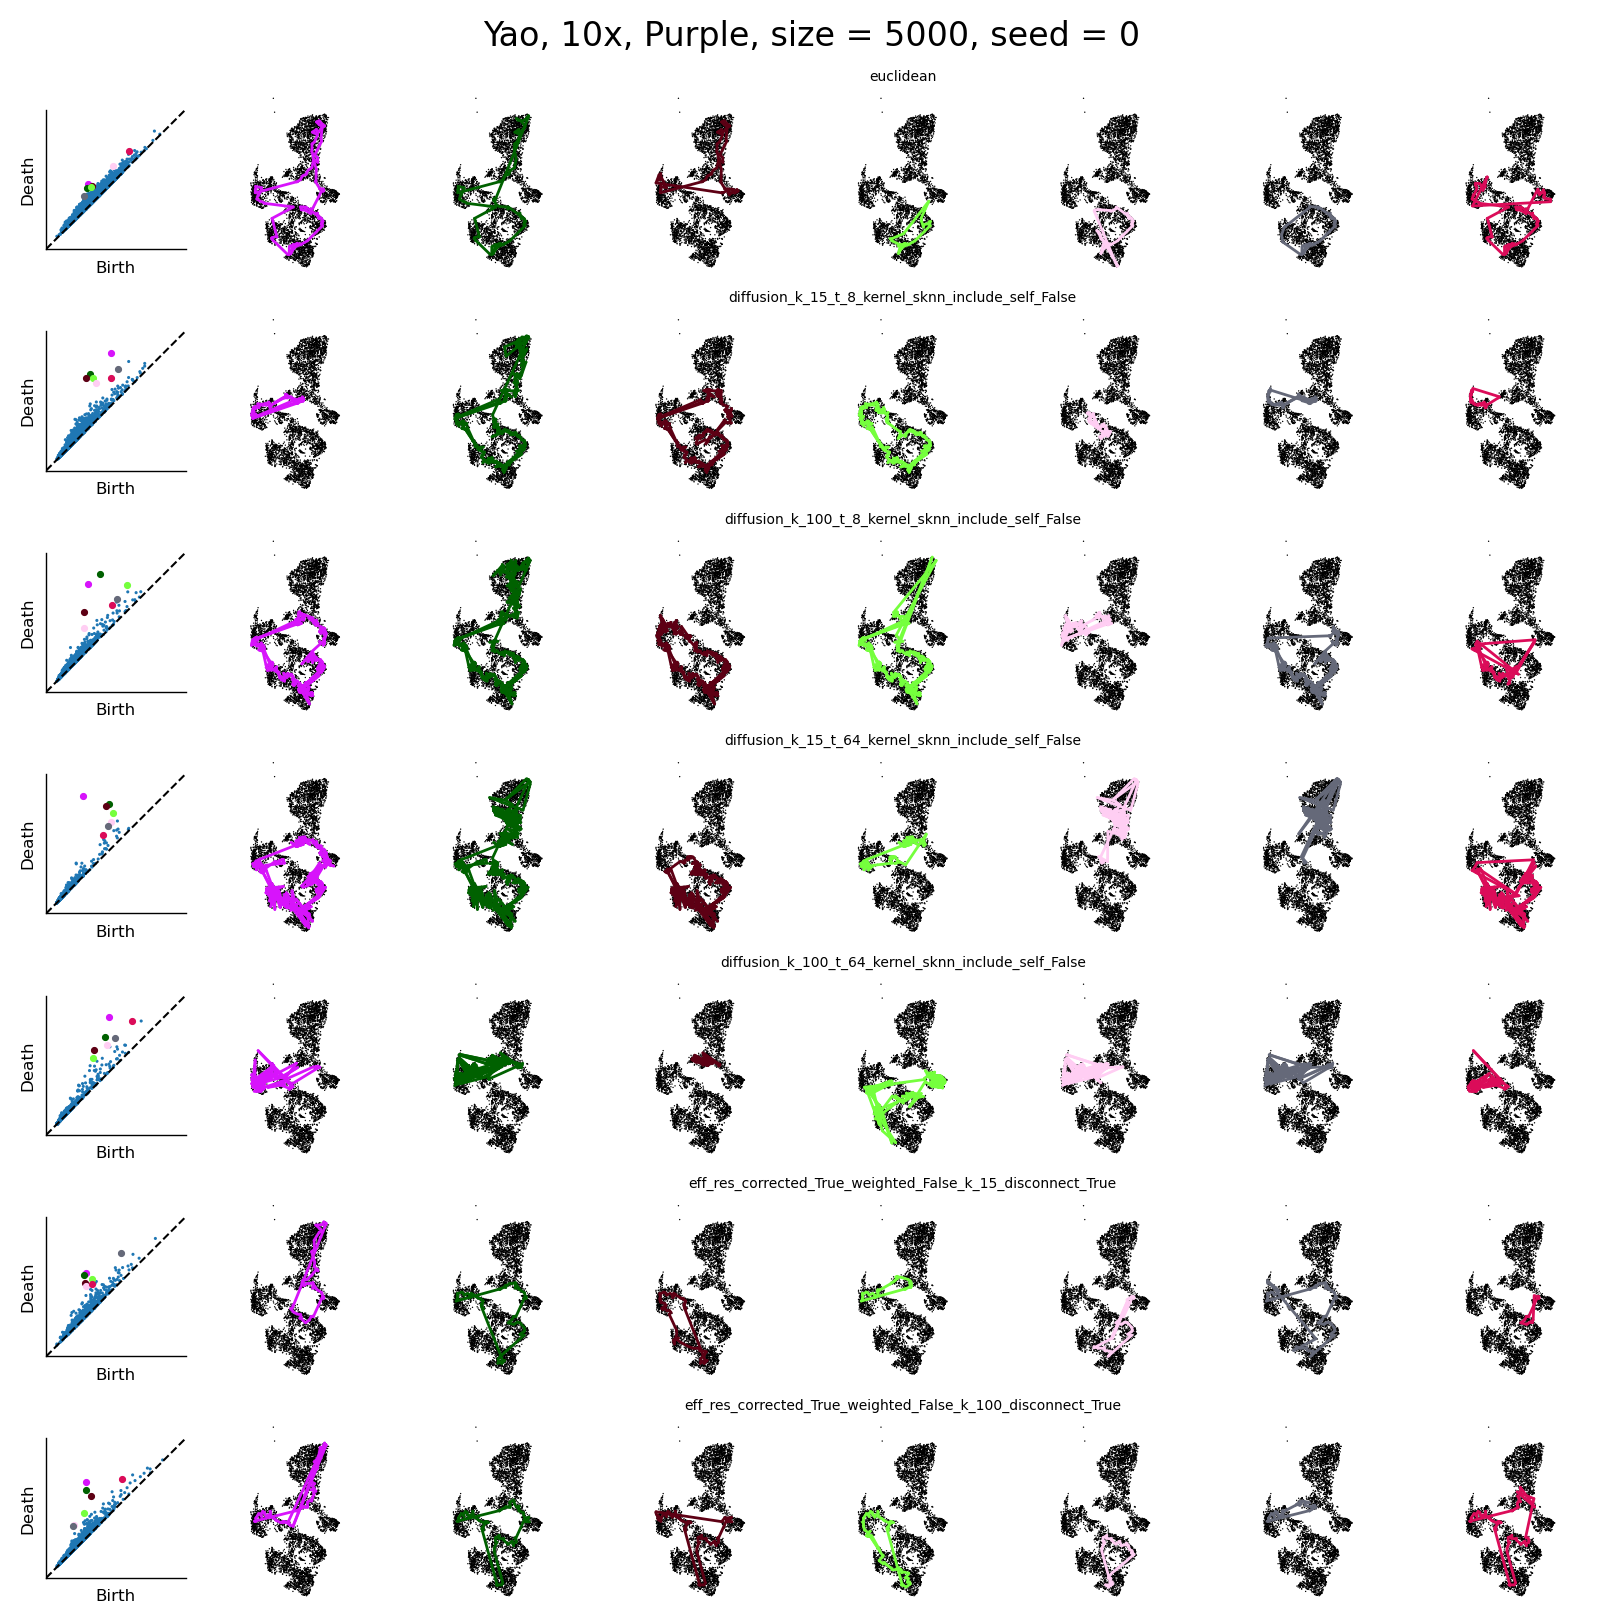

In [94]:

n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, 8), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        res = all_res_0[distance][full_dist]    #[seed]        
        
        if len(res["dgms"][1]) != 0:
            np.random.seed(0)
            mm_p = np.random.choice(len(idx_mask_purple), 5000, replace=False)
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5) 
            plot_dgm_loops(res, embd[mask_purple][mm_p], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)
        else:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            revised = res["dgms"]
            # revised[1] = np.array([[0,0],[1,1]])
            revised[1] = np.zeros((1,2))
            ax0 = ax[row][0]
            ax0.legend().set_visible(False)
            ax0.set_xticks([])
            ax0.set_yticks([])
            ax0.set_ylabel("Death")
            ax0.set_xlabel("Birth")
            plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
            for i in range(n_cols-1):
                plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
        for s in range(n_cols-1):
            ax[row][s+1].set_ylim(-30, 40)
        
        ax[row][0].legend().set_visible(False)
        ax[row][0].set_xticks([])
        ax[row][0].set_yticks([])
        ax[row][0].set_ylabel("Death")
        row+=1
fig.suptitle("Yao, 10x, Purple, size = 5000, seed = 0", fontsize = 12)       
plt.show()
fig.savefig(os.path.join(get_path("figures"), f"purple_10x_0.png"), dpi=300)


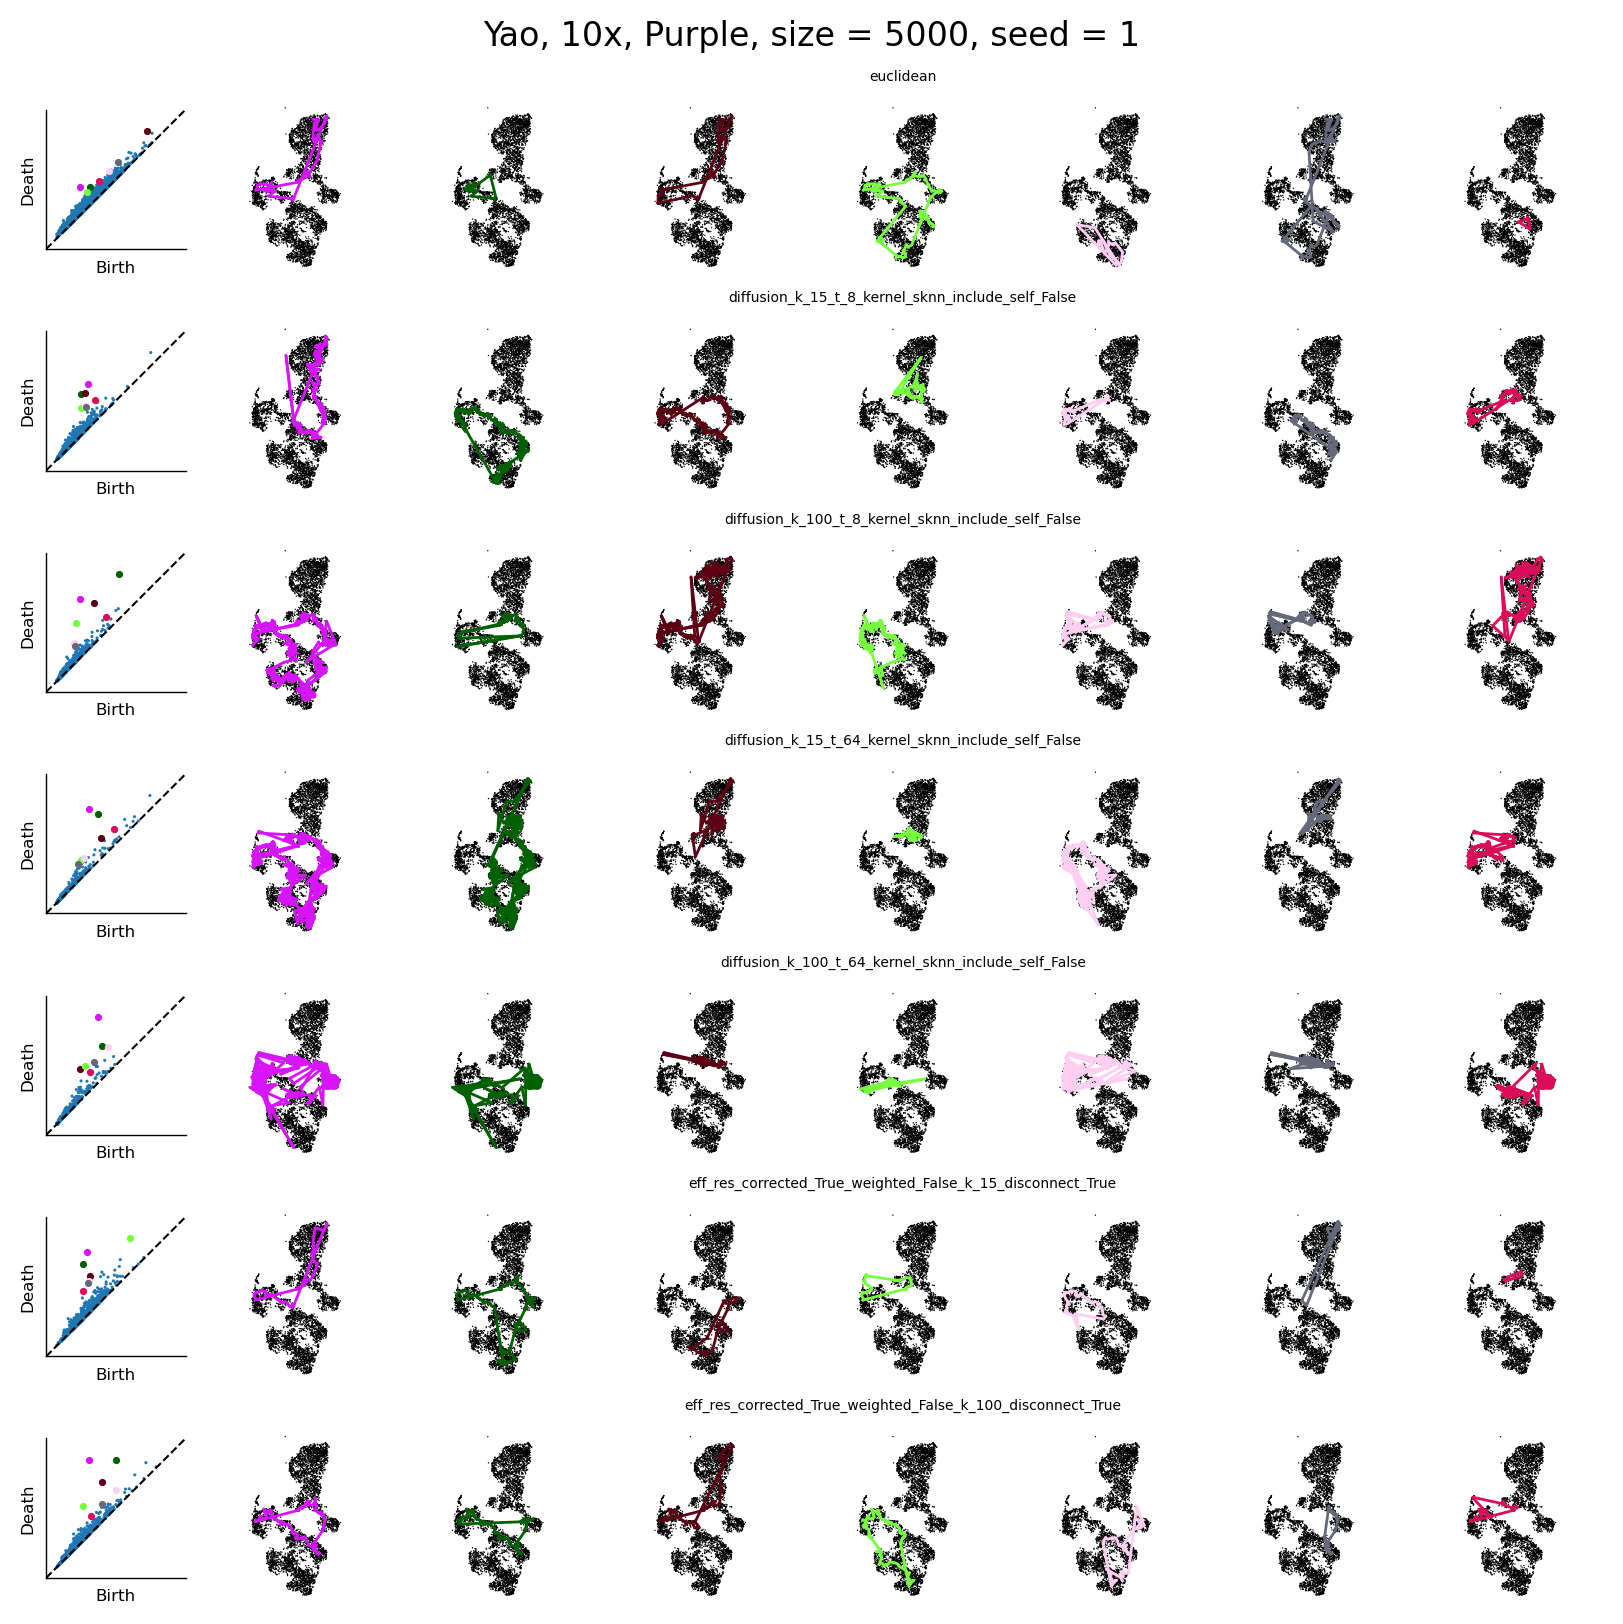

In [104]:

n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, 8), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        res = all_res_1[distance][full_dist]    #[seed]        
        
        if len(res["dgms"][1]) != 0:
            np.random.seed(1)
            mm_p = np.random.choice(len(idx_mask_purple), 5000, replace=False)
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5) 
            plot_dgm_loops(res, embd[mask_purple][mm_p], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)
        else:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            revised = res["dgms"]
            # revised[1] = np.array([[0,0],[1,1]])
            revised[1] = np.zeros((1,2))
            ax0 = ax[row][0]
            ax0.legend().set_visible(False)
            ax0.set_xticks([])
            ax0.set_yticks([])
            ax0.set_ylabel("Death")
            ax0.set_xlabel("Birth")
            plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
            for i in range(n_cols-1):
                plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
        for s in range(n_cols-1):
            ax[row][s+1].set_ylim(-30, 40)
        
        ax[row][0].legend().set_visible(False)
        ax[row][0].set_xticks([])
        ax[row][0].set_yticks([])
        ax[row][0].set_ylabel("Death")
        row+=1
fig.suptitle("Yao, 10x, Purple, size = 5000, seed = 1", fontsize = 12)       
plt.show()
fig.savefig(os.path.join(get_path("figures"), f"purple_10x_1.png"), dpi=300)



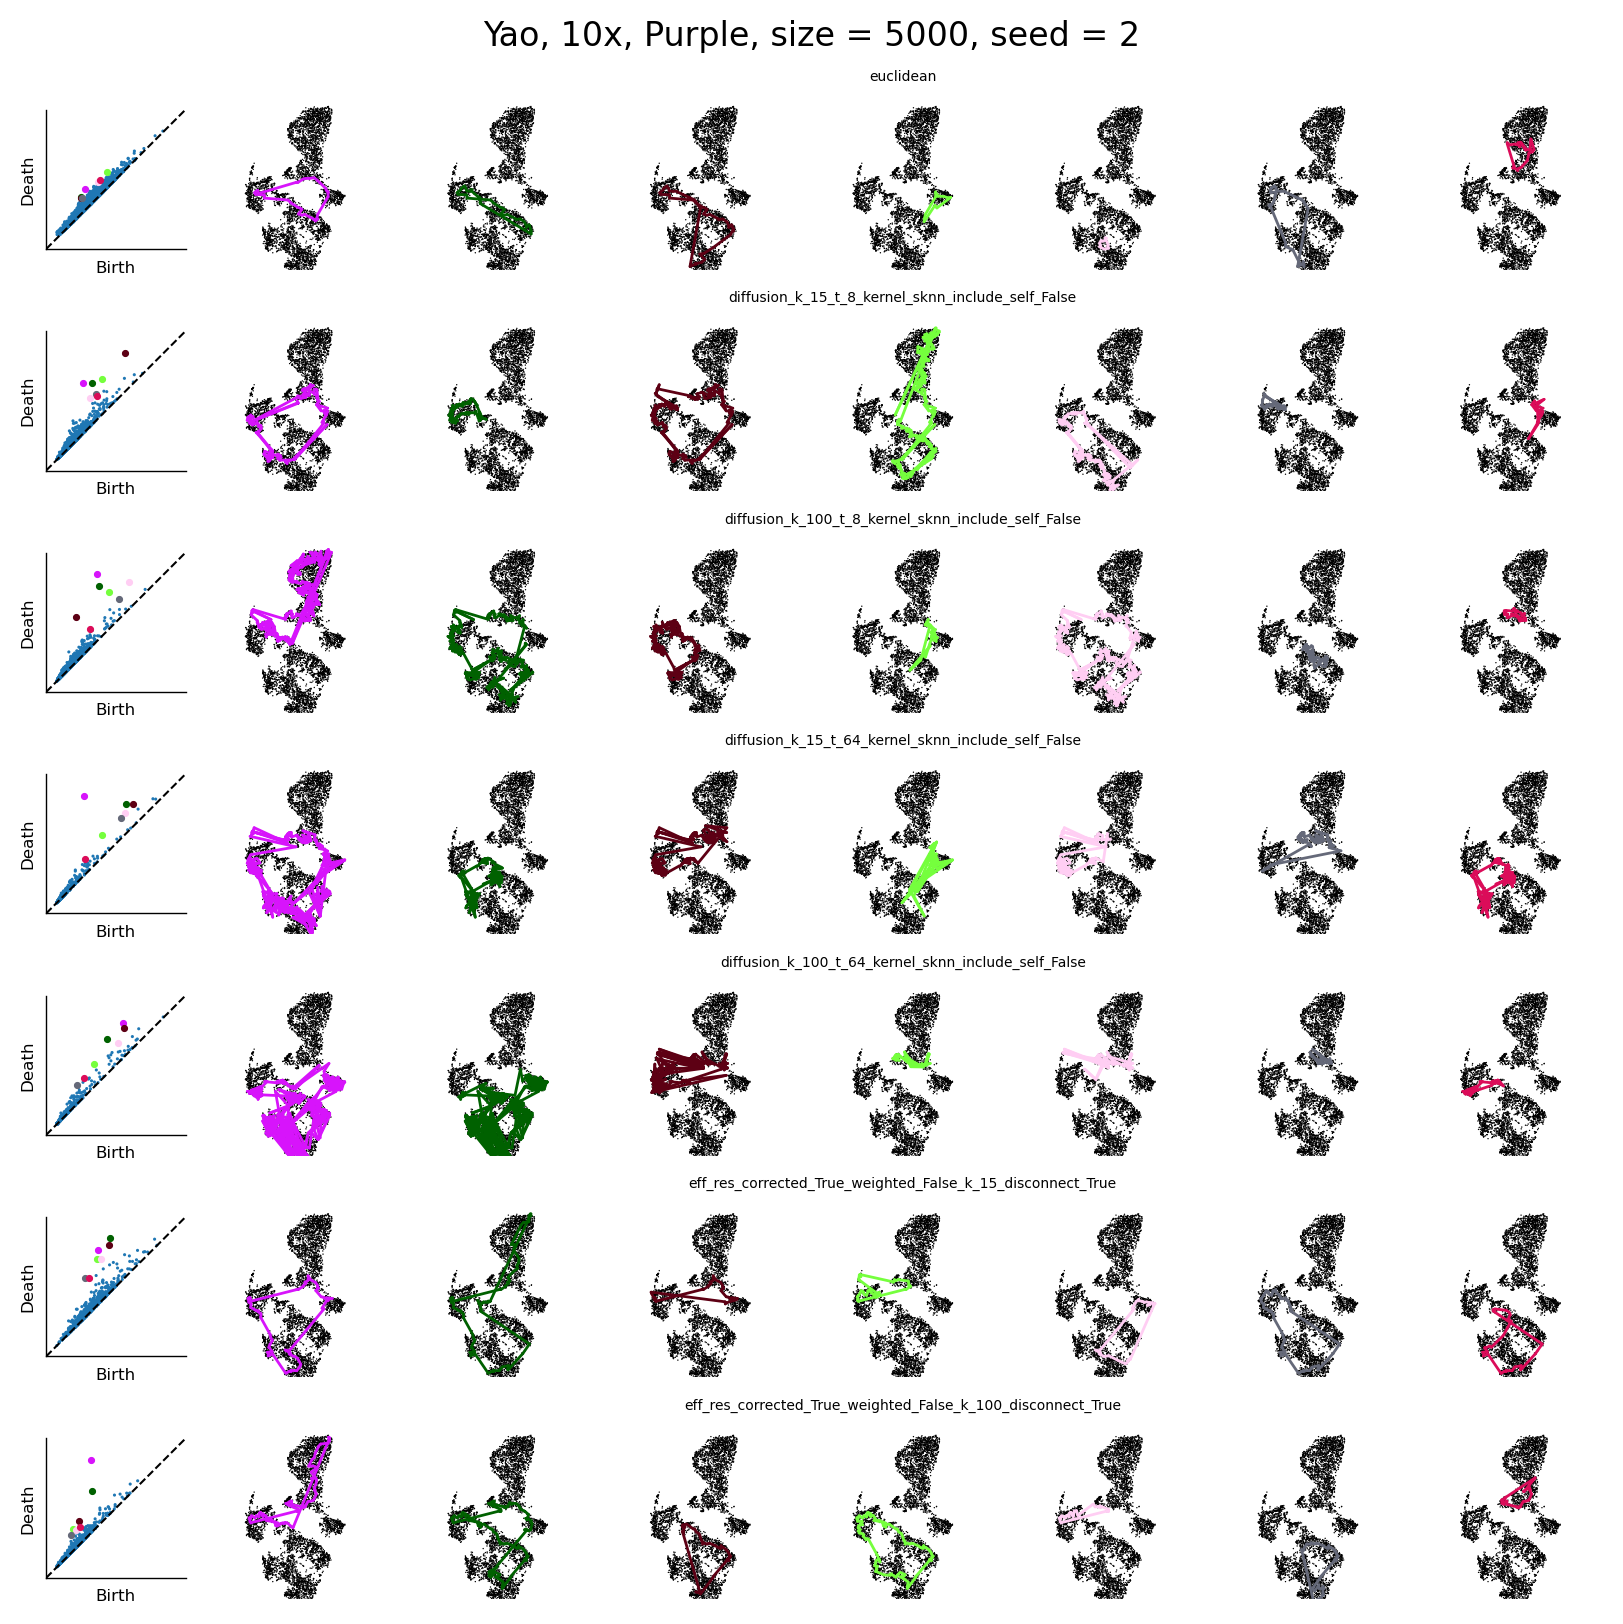

In [102]:

n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, 8), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        res = all_res_2[distance][full_dist]    #[seed]        
        
        if len(res["dgms"][1]) != 0:
            np.random.seed(2)
            mm_p = np.random.choice(len(idx_mask_purple), 5000, replace=False)
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5) 
            plot_dgm_loops(res, embd[mask_purple][mm_p], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)
        else:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            revised = res["dgms"]
            # revised[1] = np.array([[0,0],[1,1]])
            revised[1] = np.zeros((1,2))
            ax0 = ax[row][0]
            ax0.legend().set_visible(False)
            ax0.set_xticks([])
            ax0.set_yticks([])
            ax0.set_ylabel("Death")
            ax0.set_xlabel("Birth")
            plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
            for i in range(n_cols-1):
                plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
        for s in range(n_cols-1):
            ax[row][s+1].set_ylim(-30, 40)
        
        ax[row][0].legend().set_visible(False)
        ax[row][0].set_xticks([])
        ax[row][0].set_yticks([])
        ax[row][0].set_ylabel("Death")
        row+=1
fig.suptitle("Yao, 10x, Purple, size = 5000, seed = 2", fontsize = 12)       
plt.show()
fig.savefig(os.path.join(get_path("figures"), f"purple_10x_2.png"), dpi=300)



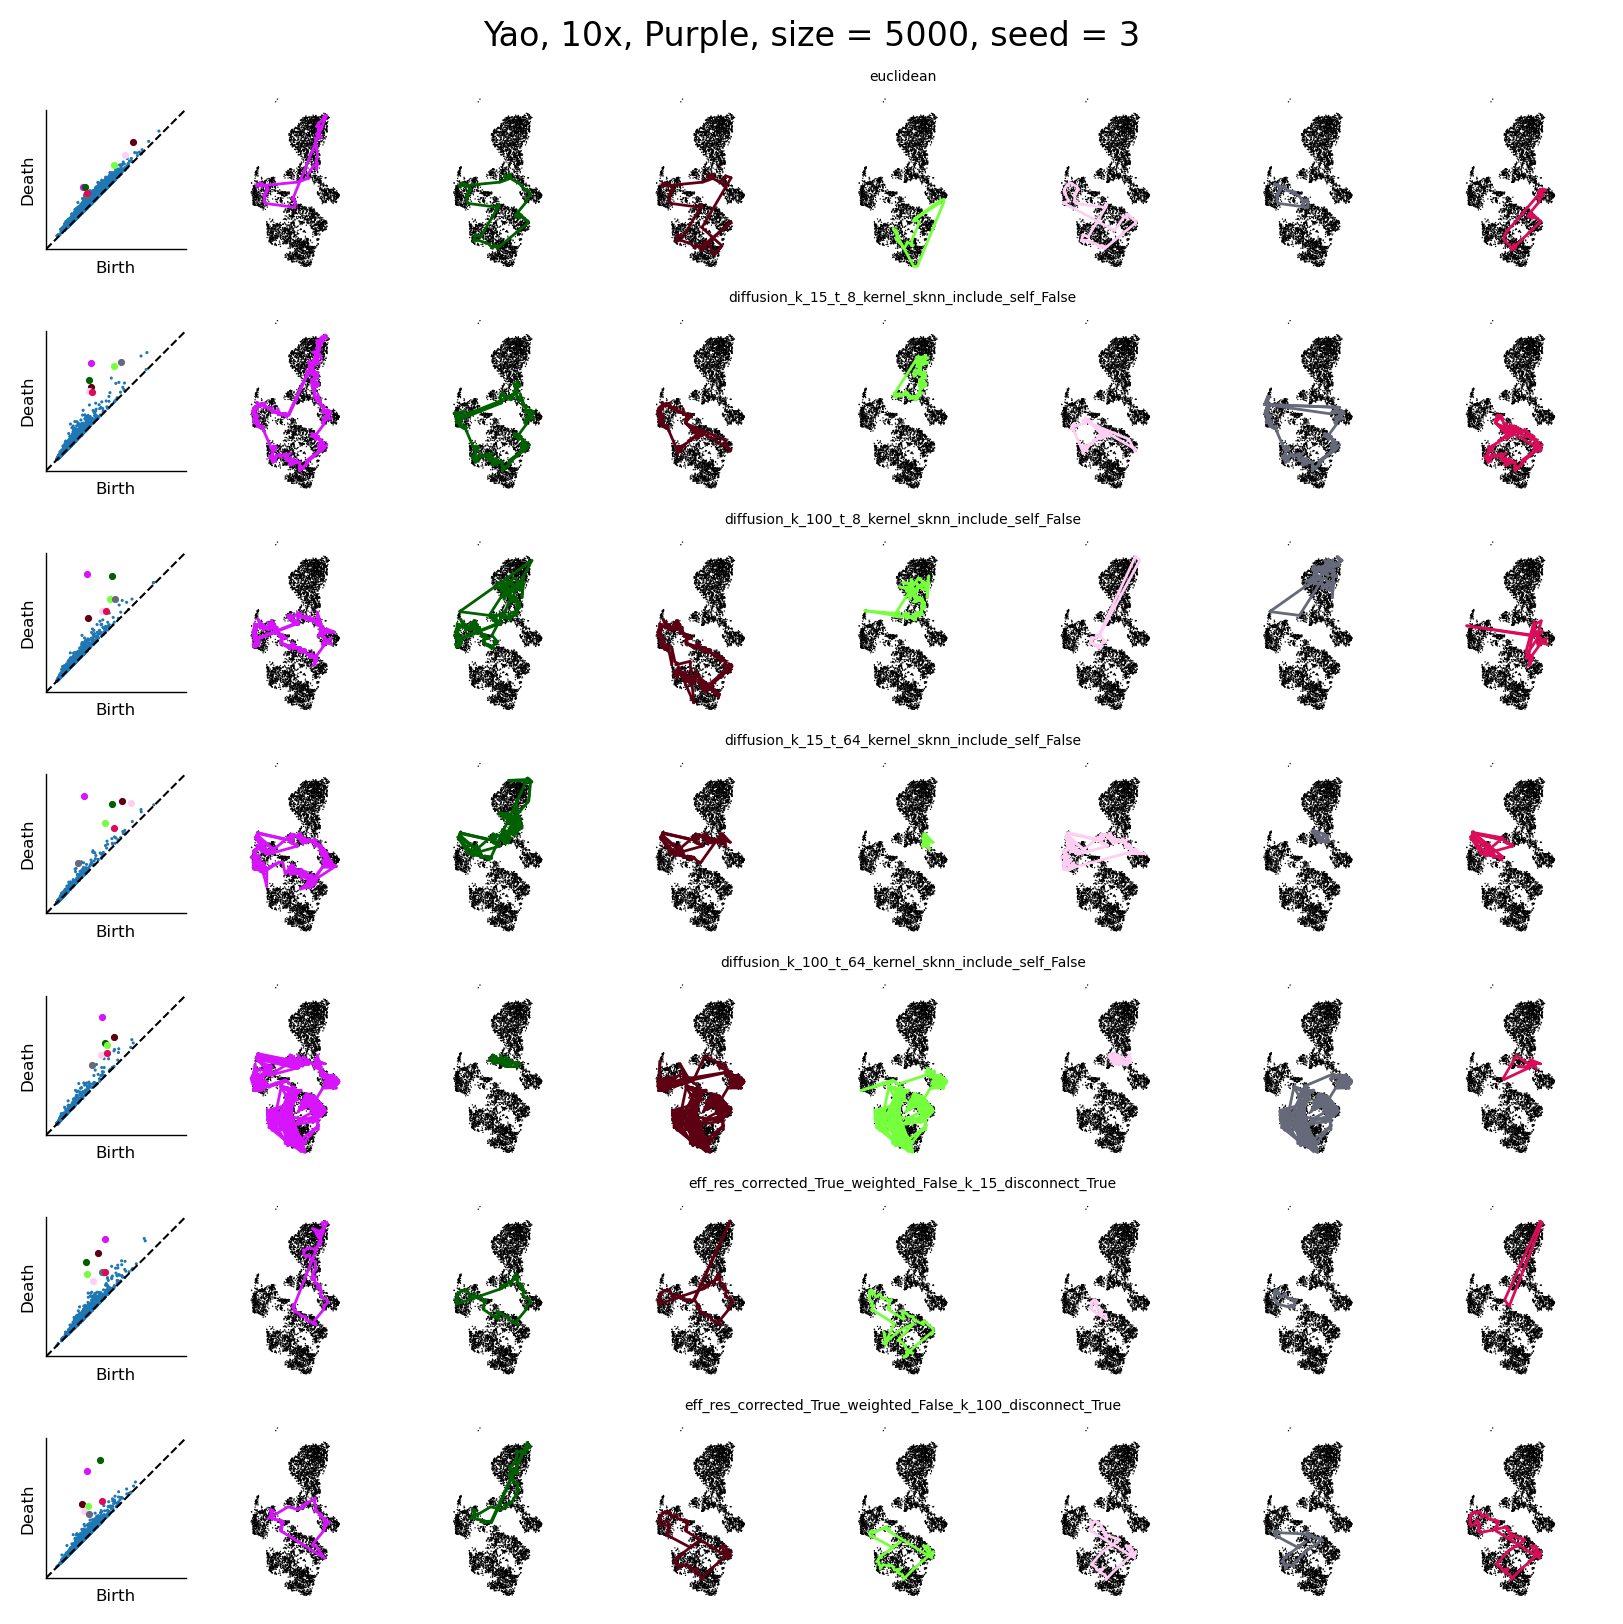

In [103]:

n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, 8), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        res = all_res_3[distance][full_dist]    #[seed]        
        
        if len(res["dgms"][1]) != 0:
            np.random.seed(3)
            mm_p = np.random.choice(len(idx_mask_purple), 5000, replace=False)
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5) 
            plot_dgm_loops(res, embd[mask_purple][mm_p], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)
        else:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            revised = res["dgms"]
            # revised[1] = np.array([[0,0],[1,1]])
            revised[1] = np.zeros((1,2))
            ax0 = ax[row][0]
            ax0.legend().set_visible(False)
            ax0.set_xticks([])
            ax0.set_yticks([])
            ax0.set_ylabel("Death")
            ax0.set_xlabel("Birth")
            plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
            for i in range(n_cols-1):
                plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
        for s in range(n_cols-1):
            ax[row][s+1].set_ylim(-30, 40)
        
        ax[row][0].legend().set_visible(False)
        ax[row][0].set_xticks([])
        ax[row][0].set_yticks([])
        ax[row][0].set_ylabel("Death")
        row+=1
fig.suptitle("Yao, 10x, Purple, size = 5000, seed = 3", fontsize = 12)       
plt.show()
fig.savefig(os.path.join(get_path("figures"), f"purple_10x_3.png"), dpi=300)


## passing cells distribution

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

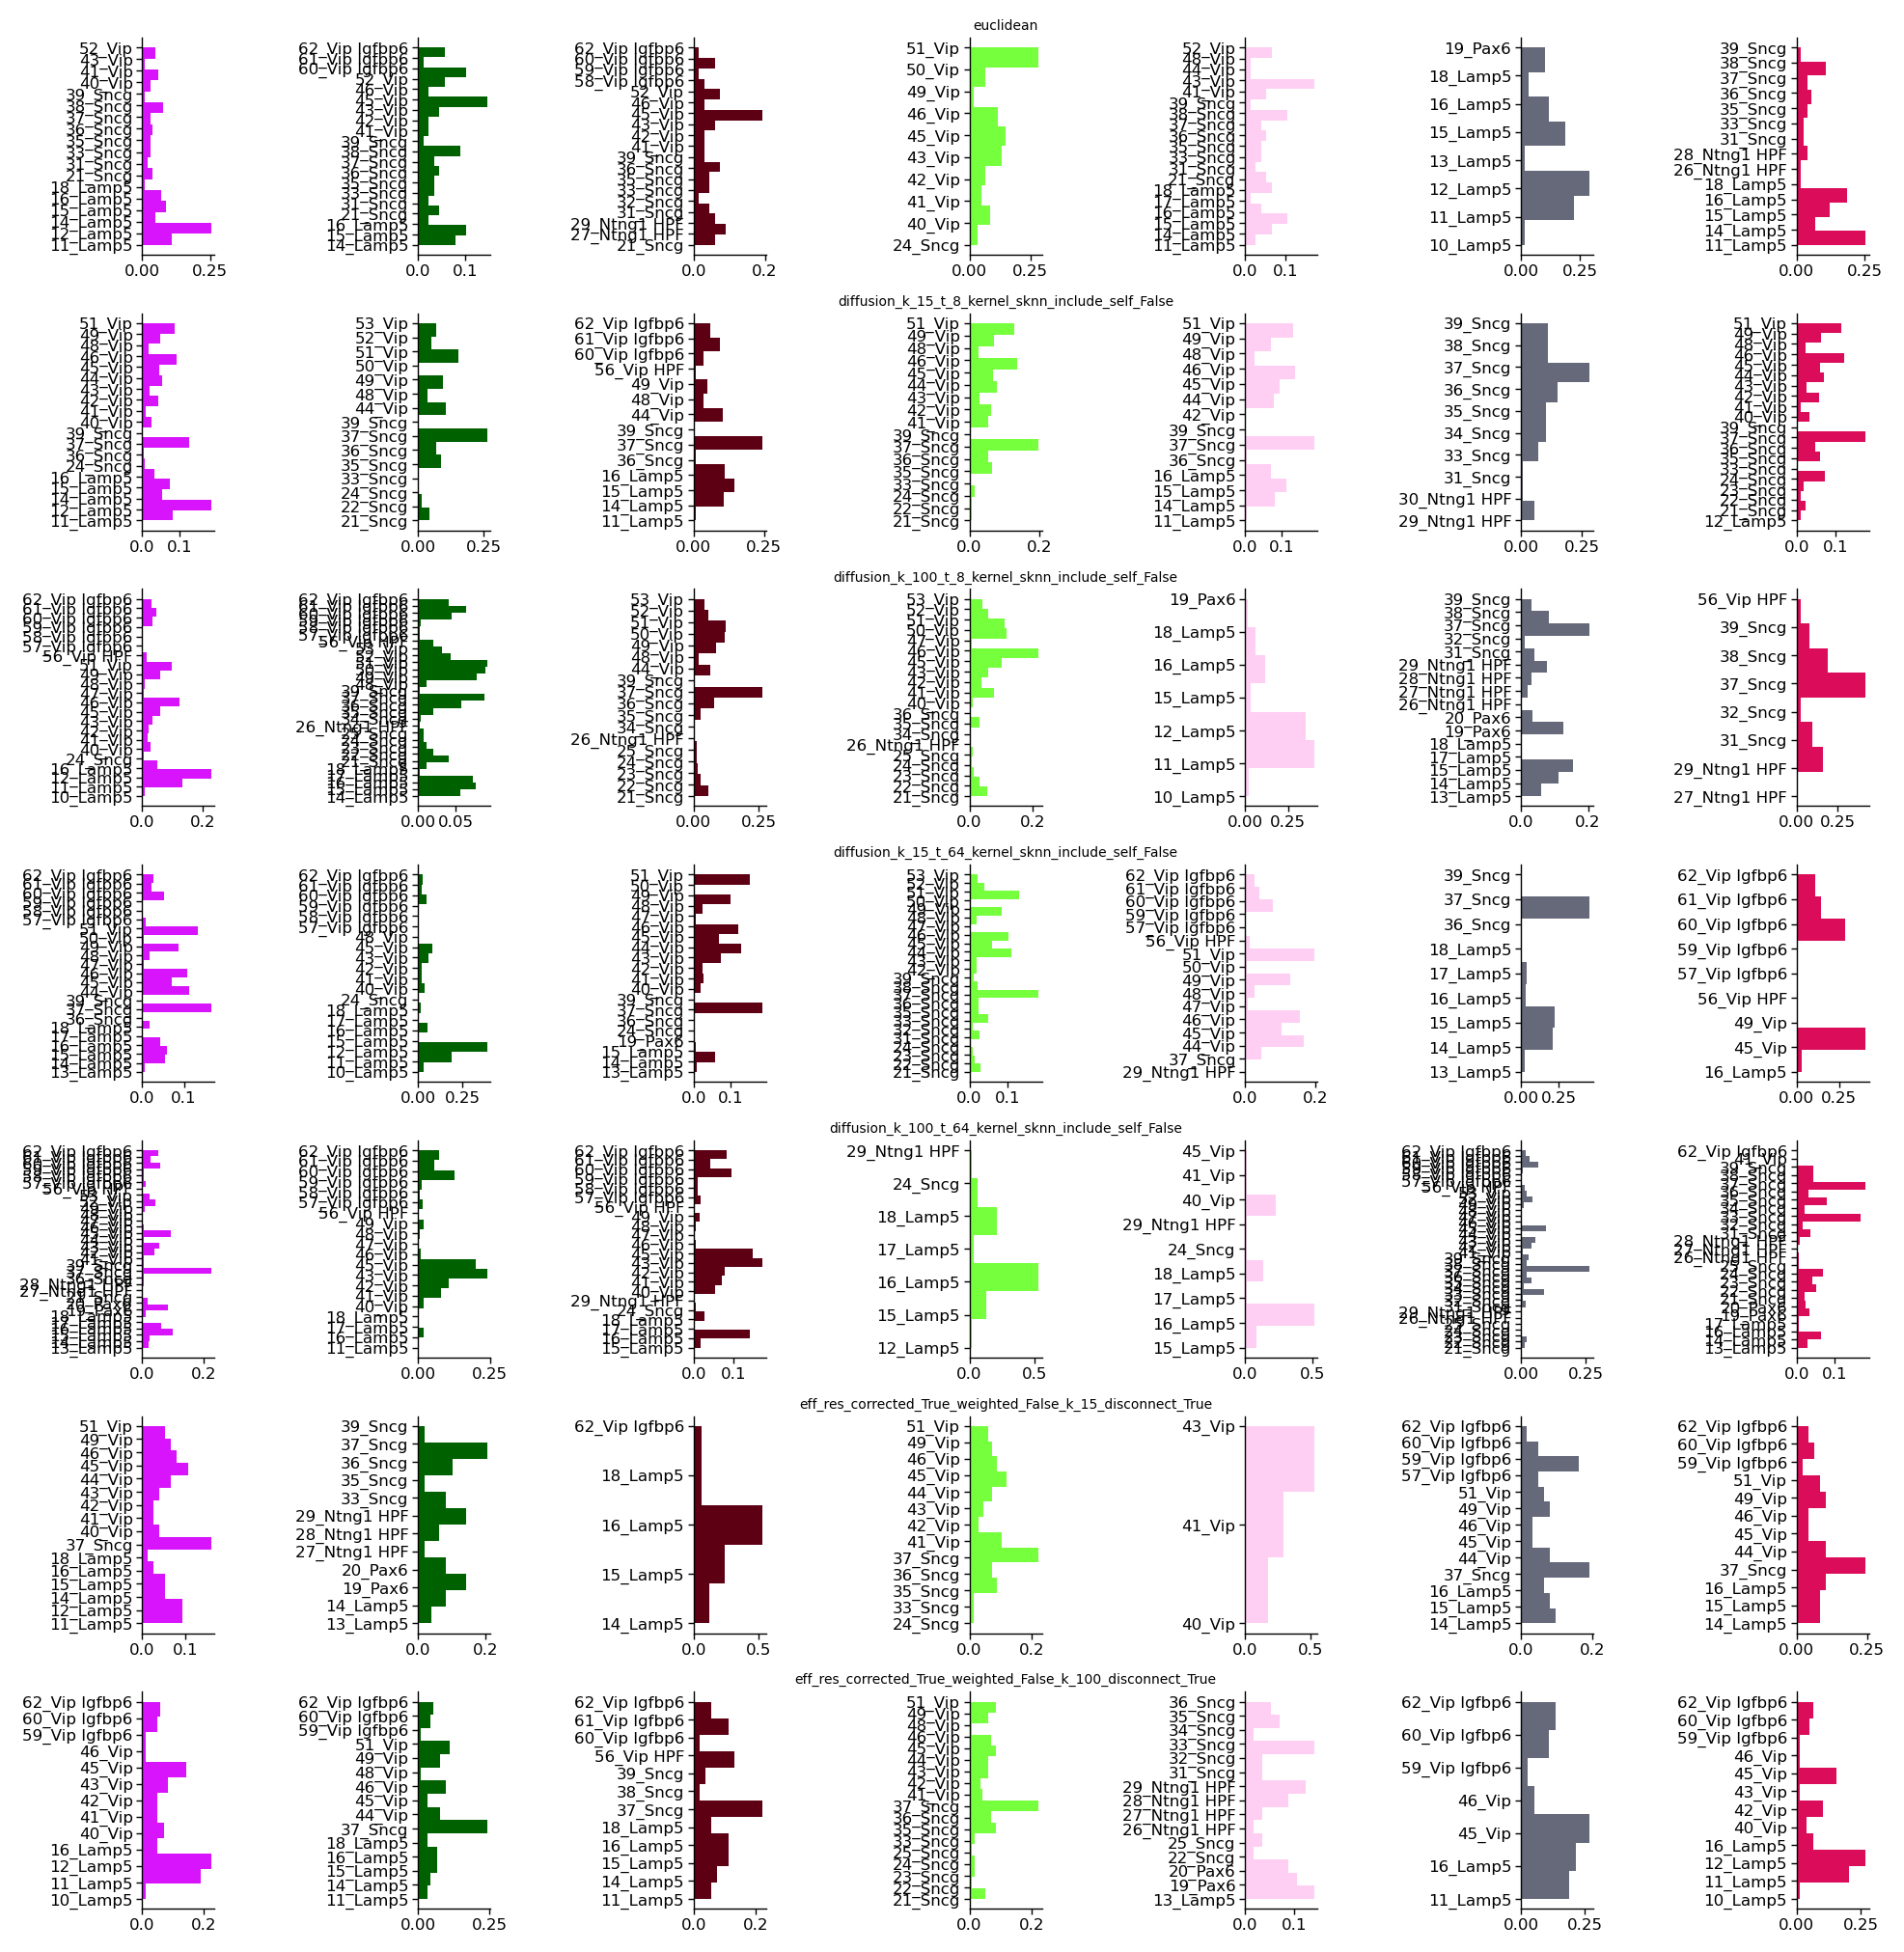

In [ ]:
n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 7
mid_col = np.floor(n_cols/2)
plot_loops = True

# '#00d2ff', 
color_list = ['#d714fb', '#006100', '#5d0014', '#75ff3d', '#ffcef3', '#656979', '#db0c59']

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, constrained_layout=True, figsize=(10, 10))
#  , width_ratios=width_ratios
seed = 0
row = 0

masked_type = full_d['clusters'][mask_purple][mm_p]

purple_10x_dict = {"cluster_purple": cluster_purple}

for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        purple_10x_dict[full_dist] = []
        
        res = all_res[distance][full_dist]   
        life_times_loops = get_life_times(res, dim=1)
        loop_idx_sorted = np.argsort(life_times_loops)[::-1][:n_cols]

        # print(loop_idx_sorted)
        # print(len(res["cycles"][1]))
        
        for k in range(n_cols):
            edge = res["cycles"][1][loop_idx_sorted[k]]
            cell_type_idx = list(set(edge.flatten()))
            
            loop_type_idx = masked_type[cell_type_idx]
            loop_type_idx = sorted(loop_type_idx)
            
            cell_type = full_d['clusterNames'][loop_type_idx]
            
            # relabel_cell_type = [tasic_to_yao[tasic_type] for tasic_type in cell_type]

            density = compute_density(list(cell_type), cluster_purple)
            purple_10x_dict[full_dist].append(density)
            
            weights= np.ones_like(loop_type_idx) / len(loop_type_idx)
            
            ax[row][k].hist(cell_type, bins = len(set(loop_type_idx)), weights = weights, orientation='horizontal', color = color_list[k]) #color_list[k]
            ax[row][k].set_box_aspect(aspect=3)
        ax[row][3].set_title(full_dist, fontsize=5)   
        row+=1
# fig.suptitle("Distribution, Tasic, Orange", fontsize = 16)
# fig.autofmt_xdate()
# plt.tight_layout()    
# plt.show()
# fig.savefig(os.path.join(get_path("figures"), f"Distri_tasic_purple.png"), dpi=300)
save_dict(purple_10x_dict, os.path.join(get_path("data"), "dist_10x_purple.pkl"))
